# A6 domain time-course simulation — v4_NewCellType

This version implements the biological cascade

\[
\text{domain change}
\longrightarrow
\text{new cell-type probabilities and labels}
\longrightarrow
\text{new gene-expression distribution}.
\]

The A6 tissue coordinates and outer boundary remain fixed. Region 12 expands toward region 13 and takes spatial support from neighboring regions. The trained cell-type MLP is then applied again using the new region labels. Finally, the trained negative-binomial gene models are evaluated after updating both the domain and cell-type dummy variables.

By default, only cells whose region label changes are assigned a newly sampled cell type. Cells outside the changing domain boundary keep their baseline cell type, which isolates the downstream effect of domain evolution.

In [1]:
from dataclasses import dataclass
from pathlib import Path
import pickle
import joblib

import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors

import torch
import torch.nn as nn

# ---------------- paths ----------------
ADATA_PATH = Path("../adata_backup_with_pred_region_celltype.h5ad")
GENE_FITS_PATH = Path("../saved_models/gene_fit_results_A6.pkl")
CELLTYPE_MODEL_PATH = Path("../saved_models/celltype_mlp_state.pt")
CELLTYPE_PREPROCESS_PATH = Path("../saved_models/celltype_preprocess.joblib")

OUT_DIR = Path("A6_domain_timecourse_v4_NewCellType")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---------------- basic settings ----------------
SLICE_ID = "A6"
REGION_KEY = "pred_region"
CELLTYPE_KEY = "pred_celltype"
SPATIAL_KEY = "spatial"
TIMES = np.array([0.0, 0.5, 1.0])

BASE_SEED = 20260622
CELLTYPE_BASE_SEED = 20260623
PLOT_GENE = "Nnat"
EXPECTED_CELLTYPE = "Ependymal"

# "changed_cells": only cells whose region changes are resampled.
# "all_cells": all cell types are independently resampled at every t > 0.
CELLTYPE_UPDATE_MODE = "changed_cells"

# The model was trained on relative coordinates in [-1, 1].
# Clipping avoids extreme extrapolation for newly expanded regions.
CELLTYPE_FEATURE_CLIP = (-1.0, 1.0)

FIELD_INTERP_K = 12
NEIGHBOR_K = 12

@dataclass(frozen=True)
class RegionAction:
    region: str
    final_area_growth: float = 0.0
    direction: object = None
    move_distance: float = 0.0
    distance_unit: str = "tissue_fraction"
    priority: float = 0.0

# Strong simulation: region 12 ends at about three times its baseline area.
REGION_ACTIONS = [
    RegionAction(
        region="12.0",
        final_area_growth=3.00,
        direction="toward:13.0",
        move_distance=0.20,
        distance_unit="tissue_fraction",
        priority=0.00
    )
]

FOCUS_REGIONS = ("12.0", "13.0")

## User-facing controls

The principal controls are all in the preceding cell:

- `REGION_ACTIONS`: active region, growth, direction, and movement distance;
- `CELLTYPE_UPDATE_MODE`: update only changed-region cells or all cells;
- `EXPECTED_CELLTYPE`: cell type expected to expand with the active region;
- `PLOT_GENE`: gene used for expression visualization.

No simulation function needs to be rewritten when these values change.

In [2]:
def smoothstep(t):
    t = np.clip(float(t), 0.0, 1.0)
    return 3.0 * t**2 - 2.0 * t**3


def numeric_sort(values):
    def key(x):
        try:
            return (0, float(x))
        except (TypeError, ValueError):
            return (1, str(x))
    return sorted(map(str, values), key=key)


def load_gene_bundle(path):
    with open(path, "rb") as f:
        obj = pickle.load(f)

    required = {"fits", "X", "X_columns", "offset"}
    if not isinstance(obj, dict) or not required.issubset(obj):
        raise ValueError(
            "The saved file must be generated by "
            "gene_expression_with_model_save.ipynb."
        )

    return {
        "fits": {str(g): v for g, v in obj["fits"].items()},
        "X": np.asarray(obj["X"], dtype=float),
        "X_columns": list(map(str, obj["X_columns"])),
        "offset": np.asarray(obj["offset"], dtype=float),
        "obs_names": obj.get("obs_names"),
    }


def signed_distance_fields(xy, labels, levels):
    # Positive inside a region and negative outside it.
    fields = np.empty((len(xy), len(levels)), dtype=float)

    for j, region in enumerate(levels):
        inside = labels == region
        outside = ~inside
        if inside.sum() == 0 or outside.sum() == 0:
            raise ValueError(f"Region {region} has an invalid cell count.")

        d_in = NearestNeighbors(n_neighbors=1).fit(
            xy[inside]
        ).kneighbors(xy, return_distance=True)[0][:, 0]

        d_out = NearestNeighbors(n_neighbors=1).fit(
            xy[outside]
        ).kneighbors(xy, return_distance=True)[0][:, 0]

        fields[:, j] = d_out - d_in

    return fields


def interpolation_neighbors(xy, k):
    k = min(max(2, int(k)), len(xy))
    return NearestNeighbors(n_neighbors=k).fit(xy)


def interpolate_field(model, xy_query, field):
    dist, idx = model.kneighbors(xy_query, return_distance=True)
    weights = 1.0 / np.maximum(dist, 1e-10) ** 2
    weights /= weights.sum(axis=1, keepdims=True)
    return np.sum(weights * field[idx], axis=1)


def resolve_direction(spec, region, centers):
    if spec is None or str(spec).lower() in {"none", "stationary"}:
        return np.zeros(2)

    if isinstance(spec, str):
        s = spec.lower()
        cardinal = {
            "left": np.array([-1.0, 0.0]),
            "right": np.array([1.0, 0.0]),
            "up": np.array([0.0, -1.0]),
            "down": np.array([0.0, 1.0]),
        }
        if s in cardinal:
            vec = cardinal[s]
        elif s.startswith("toward:"):
            target = spec.split(":", 1)[1]
            if target not in centers:
                raise ValueError(f"Unknown target region in direction: {spec}")
            vec = centers[target] - centers[region]
        elif s.startswith("away:"):
            target = spec.split(":", 1)[1]
            if target not in centers:
                raise ValueError(f"Unknown target region in direction: {spec}")
            vec = centers[region] - centers[target]
        else:
            raise ValueError(f"Unsupported direction specification: {spec}")
    else:
        vec = np.asarray(spec, dtype=float)
        if vec.shape != (2,):
            raise ValueError("A numeric direction must have length 2.")

    norm = np.linalg.norm(vec)
    return np.zeros(2) if norm == 0 else vec / norm


def action_distance(action, xy):
    if action.distance_unit == "coordinate":
        return float(action.move_distance)
    if action.distance_unit == "tissue_fraction":
        tissue_scale = min(np.ptp(xy[:, 0]), np.ptp(xy[:, 1]))
        return float(action.move_distance) * tissue_scale
    raise ValueError(
        "distance_unit must be 'coordinate' or 'tissue_fraction'."
    )


def generate_domain_trajectory(
    xy,
    baseline_labels,
    actions,
    times,
    area_weights,
    interp_k=12,
    calibration_rounds=8,
    binary_steps=45,
):
    """
    Keep coordinates fixed, transform selected region fields, and calibrate
    an additive competition bias so every active region reaches its requested
    spatial area at each time.

    Other regions are not moved explicitly. They shrink only when their fixed
    spatial points are reassigned to an expanding active region.
    """
    baseline_labels = np.asarray(baseline_labels).astype(str)
    area_weights = np.asarray(area_weights, dtype=float)
    levels = numeric_sort(pd.unique(baseline_labels))
    level_to_col = {r: j for j, r in enumerate(levels)}

    unknown = [
        str(a.region) for a in actions
        if str(a.region) not in level_to_col
    ]
    if unknown:
        raise ValueError(f"Unknown action regions: {unknown}")

    active_regions = [str(a.region) for a in actions]
    if len(active_regions) != len(set(active_regions)):
        raise ValueError("Each active region may appear only once.")

    centers = {
        r: xy[baseline_labels == r].mean(axis=0)
        for r in levels
    }
    baseline_area = {
        r: float(area_weights[baseline_labels == r].sum())
        for r in levels
    }

    base_fields = signed_distance_fields(
        xy,
        baseline_labels,
        levels
    )
    interp_model = interpolation_neighbors(
        xy,
        interp_k
    )

    spacing_model = NearestNeighbors(
        n_neighbors=min(6, len(xy))
    ).fit(xy)
    local_spacing = np.median(
        spacing_model.kneighbors(
            xy,
            return_distance=True
        )[0][:, -1]
    )

    total_area = float(area_weights.sum())
    labels_by_time = []
    score_by_time = []
    bias_by_time = []

    for t in times:
        g = smoothstep(t)

        if np.isclose(t, 0.0):
            labels_by_time.append(baseline_labels.copy())
            score_by_time.append(base_fields.copy())
            bias_by_time.append(
                {r: 0.0 for r in active_regions}
            )
            continue

        scores = base_fields.copy()
        desired_area = {}

        # Transform the shape field for every active region.
        for action in actions:
            region = str(action.region)
            j = level_to_col[region]
            c0 = centers[region]

            area_multiplier = max(
                1e-6,
                1.0 + float(action.final_area_growth) * g
            )
            desired_area[region] = min(
                baseline_area[region] * area_multiplier,
                0.95 * total_area
            )

            scale = np.sqrt(area_multiplier)
            direction = resolve_direction(
                action.direction,
                region,
                centers
            )
            shift = (
                g
                * action_distance(action, xy)
                * direction
            )
            ct = c0 + shift

            # Inverse map each fixed tissue location back to the baseline field.
            query = c0 + (xy - ct) / scale
            scores[:, j] = interpolate_field(
                interp_model,
                query,
                base_fields[:, j]
            )

            # Optional local tie-breaker when two active regions overlap.
            scores[:, j] += (
                float(action.priority)
                * g
                * local_spacing
            )

        if sum(desired_area.values()) >= total_area:
            raise ValueError(
                "The requested active-region areas occupy the entire tissue. "
                "Reduce final_area_growth."
            )

        # Coordinate descent on additive biases. For one active region this
        # gives the requested area directly; for two regions it iterates until
        # both area targets are simultaneously close.
        biases = np.zeros(len(levels), dtype=float)
        active_columns = [
            level_to_col[str(a.region)]
            for a in actions
        ]

        for _ in range(max(1, calibration_rounds)):
            for action in sorted(
                actions,
                key=lambda a: float(a.priority)
            ):
                region = str(action.region)
                j = level_to_col[region]

                adjusted = scores + biases[None, :]
                other_columns = [
                    k for k in range(len(levels))
                    if k != j
                ]
                max_other = adjusted[:, other_columns].max(axis=1)
                margin = max_other - scores[:, j]

                lo = float(margin.min() - 4.0 * local_spacing)
                hi = float(margin.max() + 4.0 * local_spacing)
                target = desired_area[region]

                for _ in range(binary_steps):
                    mid = 0.5 * (lo + hi)
                    won_area = float(
                        area_weights[margin <= mid].sum()
                    )
                    if won_area < target:
                        lo = mid
                    else:
                        hi = mid

                biases[j] = 0.5 * (lo + hi)

        adjusted_scores = scores + biases[None, :]
        current = np.asarray(levels)[
            np.argmax(adjusted_scores, axis=1)
        ]

        labels_by_time.append(current)
        score_by_time.append(adjusted_scores)
        bias_by_time.append({
            r: float(biases[level_to_col[r]])
            for r in active_regions
        })

    return (
        labels_by_time,
        score_by_time,
        levels,
        bias_by_time,
    )

def build_knn_graph(xy, k=12):
    k = min(max(2, int(k)) + 1, len(xy))
    return (
        NearestNeighbors(n_neighbors=k)
        .fit(xy)
        .kneighbors(return_distance=False)[:, 1:]
    )


def neighboring_regions(labels, region, neighbors):
    region = str(region)
    rows = np.where(labels == region)[0]
    values = labels[neighbors[rows]].ravel()
    return numeric_sort(set(values) - {region})


def contact_edge_count(labels, region_a, region_b, neighbors):
    labels = np.asarray(labels).astype(str)
    a, b = str(region_a), str(region_b)
    src = np.repeat(
        np.arange(len(labels)),
        neighbors.shape[1]
    )
    dst = neighbors.ravel()
    pair = (
        ((labels[src] == a) & (labels[dst] == b))
        | ((labels[src] == b) & (labels[dst] == a))
    )
    return int(pair.sum() // 2)


def local_area_weights(xy, k=6):
    # Approximate the spatial area represented by each point.
    k = min(max(3, int(k)), len(xy))
    dist = (
        NearestNeighbors(n_neighbors=k)
        .fit(xy)
        .kneighbors(
            xy,
            return_distance=True
        )[0][:, -1]
    )
    return np.maximum(dist, 1e-10) ** 2

In [3]:
# ---------- cell-type model and inference functions ----------
class SpatialProbMLP(nn.Module):
    def __init__(self, input_dim, n_celltypes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, n_celltypes)
        )

    def forward(self, x):
        return torch.softmax(self.net(x), dim=1)


def load_celltype_model(model_path, preprocess_path):
    preprocess = joblib.load(preprocess_path)

    model = SpatialProbMLP(
        input_dim=int(preprocess["input_dim"]),
        n_celltypes=int(preprocess["n_celltypes"])
    )

    try:
        state = torch.load(
            model_path,
            map_location="cpu",
            weights_only=True
        )
    except TypeError:
        state = torch.load(
            model_path,
            map_location="cpu"
        )

    model.load_state_dict(state)
    model.eval()

    preprocess["region_categories_str"] = [
        str(x) for x in preprocess["region_categories"]
    ]
    preprocess["celltype_names"] = [
        str(x).replace("prob_", "")
        for x in preprocess["prob_cols"]
    ]
    preprocess["region_coordinate_transforms_str"] = {
        str(k): v
        for k, v in preprocess[
            "region_coordinate_transforms"
        ].items()
    }

    return model, preprocess


def build_celltype_features(
    coords_3d,
    region_labels,
    preprocess,
    clip=(-1.0, 1.0),
):
    """
    Rebuild the exact feature type used during cell-type training:
    region-specific PCA-relative coordinates plus region one-hot.
    """
    coords_3d = np.asarray(coords_3d, dtype=float)
    region_labels = np.asarray(region_labels).astype(str)

    categories = preprocess["region_categories_str"]
    transforms = preprocess[
        "region_coordinate_transforms_str"
    ]
    category_index = {
        r: j for j, r in enumerate(categories)
    }

    unknown = sorted(
        set(region_labels) - set(categories)
    )
    if unknown:
        raise ValueError(
            f"Regions absent from the saved cell-type model: {unknown}"
        )

    relative = np.zeros(
        (len(region_labels), 3),
        dtype=float
    )

    for region in np.unique(region_labels):
        mask = region_labels == region
        transform = transforms.get(region)
        if transform is None:
            raise KeyError(
                f"No saved coordinate transform for region {region}."
            )

        xyz_r = coords_3d[mask]
        pca = transform["pca"]

        if pca is None:
            projected = xyz_r.copy()
        else:
            projected = pca.transform(xyz_r)

        min_xyz = np.asarray(
            transform["min_xyz"],
            dtype=float
        )
        scale = np.asarray(
            transform["scale"],
            dtype=float
        )
        scale = np.where(
            scale < 1e-6,
            1.0,
            scale
        )

        rel = 2.0 * (
            projected - min_xyz
        ) / scale - 1.0

        if clip is not None:
            rel = np.clip(
                rel,
                clip[0],
                clip[1]
            )

        relative[mask] = rel

    onehot = np.zeros(
        (len(region_labels), len(categories)),
        dtype=float
    )
    for i, region in enumerate(region_labels):
        onehot[i, category_index[region]] = 1.0

    X = np.concatenate(
        [relative, onehot],
        axis=1
    )

    if X.shape[1] != int(preprocess["input_dim"]):
        raise ValueError(
            f"Cell-type feature dimension {X.shape[1]} "
            f"does not equal saved input dimension "
            f"{preprocess['input_dim']}."
        )

    return X


def predict_celltype_probabilities(
    model,
    preprocess,
    coords_3d,
    region_labels,
    clip=(-1.0, 1.0),
):
    X = build_celltype_features(
        coords_3d=coords_3d,
        region_labels=region_labels,
        preprocess=preprocess,
        clip=clip
    )

    with torch.no_grad():
        P = model(
            torch.tensor(
                X,
                dtype=torch.float32
            )
        ).cpu().numpy()

    P = np.maximum(P, 0.0)
    P /= np.maximum(
        P.sum(axis=1, keepdims=True),
        1e-12
    )
    return P


def sample_probability_rows(
    probabilities,
    names,
    seed,
):
    rng = np.random.default_rng(seed)
    cumulative = np.cumsum(
        probabilities,
        axis=1
    )
    u = rng.random(
        len(probabilities)
    )
    index = (
        u[:, None] > cumulative
    ).sum(axis=1)
    index = np.minimum(
        index,
        len(names) - 1
    )
    return np.asarray(names)[index]


def regenerate_celltypes(
    baseline_celltypes,
    baseline_regions,
    regions_by_time,
    probabilities_by_time,
    celltype_names,
    times,
    mode="changed_cells",
    base_seed=20260623,
):
    baseline_celltypes = np.asarray(
        baseline_celltypes
    ).astype(str)
    baseline_regions = np.asarray(
        baseline_regions
    ).astype(str)

    output = []

    for h, (t, region_t, P_t) in enumerate(
        zip(
            times,
            regions_by_time,
            probabilities_by_time
        )
    ):
        if np.isclose(t, 0.0):
            output.append(
                baseline_celltypes.copy()
            )
            continue

        sampled = sample_probability_rows(
            P_t,
            celltype_names,
            seed=base_seed + 10_000 * h
        )

        if mode == "changed_cells":
            current = baseline_celltypes.copy()
            changed = (
                np.asarray(region_t).astype(str)
                != baseline_regions
            )
            current[changed] = sampled[changed]
        elif mode == "all_cells":
            current = sampled
        else:
            raise ValueError(
                "CELLTYPE_UPDATE_MODE must be "
                "'changed_cells' or 'all_cells'."
            )

        output.append(current)

    return output

In [4]:
# ---------- load A6 and create the domain trajectory ----------
adata = sc.read(ADATA_PATH)
a6 = adata[
    adata.obs["batch"].astype(str) == SLICE_ID
].copy()

gene_bundle = load_gene_bundle(
    GENE_FITS_PATH
)
celltype_model, celltype_preprocess = (
    load_celltype_model(
        CELLTYPE_MODEL_PATH,
        CELLTYPE_PREPROCESS_PATH
    )
)

saved_obs = gene_bundle["obs_names"]
if saved_obs is not None:
    saved_obs = list(map(str, saved_obs))
    if set(saved_obs) != set(
        map(str, a6.obs_names)
    ):
        raise ValueError(
            "Saved gene fits were not trained on exactly "
            "the current A6 cells."
        )
    a6 = a6[saved_obs].copy()

for key in (REGION_KEY, CELLTYPE_KEY):
    if key not in a6.obs:
        raise KeyError(
            f"Missing a6.obs[{key!r}]."
        )

xy = np.asarray(
    a6.obsm[SPATIAL_KEY][:, :2],
    dtype=float
)
z = np.asarray(
    a6.obs["z"],
    dtype=float
)

ct_spatial_key = str(
    celltype_preprocess["spatial_key"]
)
if ct_spatial_key in a6.obsm:
    coords_celltype = np.asarray(
        a6.obsm[ct_spatial_key][:, :3],
        dtype=float
    )
else:
    coords_celltype = np.column_stack(
        [xy, z]
    )

baseline_regions = (
    a6.obs[REGION_KEY]
    .astype(str)
    .to_numpy()
)
baseline_celltypes = (
    a6.obs[CELLTYPE_KEY]
    .astype(str)
    .to_numpy()
)
genes = a6.var_names.astype(str).tolist()

area_weights = local_area_weights(xy)

(
    regions_by_time,
    score_by_time,
    region_levels,
    bias_by_time,
) = generate_domain_trajectory(
    xy=xy,
    baseline_labels=baseline_regions,
    actions=REGION_ACTIONS,
    times=TIMES,
    area_weights=area_weights,
    interp_k=FIELD_INTERP_K,
)

neighbors = build_knn_graph(
    xy,
    NEIGHBOR_K
)

print("A6 cells:", a6.n_obs)
print("Cell-type update mode:", CELLTYPE_UPDATE_MODE)
print("Region actions:")
for action in REGION_ACTIONS:
    print(" ", action)

print("\nActual domain-label changes:")
for t, labels_t, biases_t in zip(
    TIMES,
    regions_by_time,
    bias_by_time
):
    print(
        f"time={t:g}: "
        f"changed cells="
        f"{np.sum(labels_t != baseline_regions)}, "
        f"region12 cells="
        f"{np.sum(labels_t == '12.0')}, "
        f"region13 cells="
        f"{np.sum(labels_t == '13.0')}, "
        f"biases={biases_t}"
    )

A6 cells: 5488
Cell-type update mode: changed_cells
Region actions:
  RegionAction(region='12.0', final_area_growth=3.0, direction='toward:13.0', move_distance=0.2, distance_unit='tissue_fraction', priority=0.0)

Actual domain-label changes:
time=0: changed cells=0, region12 cells=344, region13 cells=103, biases={'12.0': 0.0}
time=0.5: changed cells=378, region12 cells=722, region13 cells=80, biases={'12.0': 77.31216367157313}
time=1: changed cells=744, region12 cells=1088, region13 cells=52, biases={'12.0': 112.53689773329432}


In [11]:
# ---------- regenerate cell-type probabilities and labels ----------
celltype_probabilities_by_time = [
    predict_celltype_probabilities(
        model=celltype_model,
        preprocess=celltype_preprocess,
        coords_3d=coords_celltype,
        region_labels=labels_t,
        clip=CELLTYPE_FEATURE_CLIP
    )
    for labels_t in regions_by_time
]

celltype_names = np.asarray(
    celltype_preprocess["celltype_names"]
)

celltypes_by_time = regenerate_celltypes(
    baseline_celltypes=baseline_celltypes,
    baseline_regions=baseline_regions,
    regions_by_time=regions_by_time,
    probabilities_by_time=celltype_probabilities_by_time,
    celltype_names=celltype_names,
    times=TIMES,
    mode=CELLTYPE_UPDATE_MODE,
    base_seed=CELLTYPE_BASE_SEED
)

ep_idx = list(celltype_names).index("Ependymal")

baseline_region12 = baseline_regions == "12.0"
baseline_ep_prop = np.mean(
    baseline_celltypes[baseline_region12] == "Ependymal"
)

print(
    "Baseline Ependymal proportion in region 12:",
    baseline_ep_prop
)

for h, t in enumerate(TIMES):
    entered12 = (
        (regions_by_time[h] == "12.0")
        & (baseline_regions != "12.0")
    )

    if entered12.sum() == 0:
        print(f"time={t:g}: no cells entered region 12")
        continue

    print(
        f"\ntime={t:g}",
        f"\n  cells entering region 12: {entered12.sum()}",
        f"\n  mean predicted Ependymal probability: "
        f"{celltype_probabilities_by_time[h][entered12, ep_idx].mean():.4f}",
        f"\n  sampled Ependymal proportion: "
        f"{np.mean(celltypes_by_time[h][entered12] == 'Ependymal'):.4f}"
    )

if EXPECTED_CELLTYPE not in set(celltype_names):
    raise KeyError(
        f"{EXPECTED_CELLTYPE!r} is not an output "
        "of the saved cell-type model."
    )

expected_celltype_index = int(
    np.where(
        celltype_names == EXPECTED_CELLTYPE
    )[0][0]
)

print(
    f"\n{EXPECTED_CELLTYPE} changes:"
)
for h, t in enumerate(TIMES):
    region12 = (
        regions_by_time[h] == "12.0"
    )
    changed_region = (
        regions_by_time[h]
        != baseline_regions
    )
    changed_celltype = (
        celltypes_by_time[h]
        != baseline_celltypes
    )

    print(
        f"time={t:g}: "
        f"changed cell types={changed_celltype.sum()}, "
        f"{EXPECTED_CELLTYPE} count="
        f"{np.sum(celltypes_by_time[h] == EXPECTED_CELLTYPE)}, "
        f"{EXPECTED_CELLTYPE} proportion in region12="
        f"{np.mean(celltypes_by_time[h][region12] == EXPECTED_CELLTYPE):.4f}, "
        f"mean model probability in region12="
        f"{celltype_probabilities_by_time[h][region12, expected_celltype_index].mean():.4f}, "
        f"region-changed cells={changed_region.sum()}"
    )

Baseline Ependymal proportion in region 12: 0.5872093023255814
time=0: no cells entered region 12

time=0.5 
  cells entering region 12: 378 
  mean predicted Ependymal probability: 0.2372 
  sampled Ependymal proportion: 0.2619

time=1 
  cells entering region 12: 744 
  mean predicted Ependymal probability: 0.1917 
  sampled Ependymal proportion: 0.2056

Ependymal changes:
time=0: changed cell types=0, Ependymal count=252, Ependymal proportion in region12=0.5872, mean model probability in region12=0.6011, region-changed cells=0
time=0.5: changed cell types=273, Ependymal count=310, Ependymal proportion in region12=0.4169, mean model probability in region12=0.4106, region-changed cells=378
time=1: changed cell types=504, Ependymal count=359, Ependymal proportion in region12=0.3263, mean model probability in region12=0.3212, region-changed cells=744


In [6]:
# ---------- update both domain and cell-type columns in the gene design ----------
X0 = gene_bundle["X"]
X_columns = gene_bundle["X_columns"]

if X0.shape[0] != a6.n_obs:
    raise ValueError(
        f"The saved design matrix has {X0.shape[0]} rows, "
        f"but A6 has {a6.n_obs} cells."
    )

region_set = set(region_levels)
celltype_set = set(
    map(str, celltype_names)
)

domain_columns = [
    c for c in X_columns
    if c in region_set
]
celltype_columns = [
    c for c in X_columns
    if c in celltype_set
]

domain_column_index = {
    c: X_columns.index(c)
    for c in domain_columns
}
celltype_column_index = {
    c: X_columns.index(c)
    for c in celltype_columns
}

if not domain_columns:
    raise ValueError(
        "No domain dummy columns were found."
    )
if not celltype_columns:
    raise ValueError(
        "No cell-type dummy columns were found."
    )

print("Domain dummy columns:", domain_columns)
print(
    "Domain reference level:",
    [r for r in region_levels if r not in domain_columns]
)
print("Cell-type dummy columns:", celltype_columns)
print(
    "Cell-type reference level:",
    [
        c for c in celltype_names
        if c not in celltype_columns
    ]
)

X_by_time = []

for regions_t, celltypes_t in zip(
    regions_by_time,
    celltypes_by_time
):
    Xt = X0.copy()

    for region, j in domain_column_index.items():
        Xt[:, j] = (
            regions_t == region
        ).astype(float)

    for celltype, j in celltype_column_index.items():
        Xt[:, j] = (
            celltypes_t == celltype
        ).astype(float)

    X_by_time.append(Xt)

# At t=0 the rebuilt design should reproduce the fitted baseline design.
print(
    "Maximum t=0 design-matrix difference:",
    np.max(np.abs(X_by_time[0] - X0))
)


def simulate_expression_times(
    bundle,
    genes,
    X_by_time,
    times,
    base_seed,
):
    counts = [
        np.zeros(
            (
                X_by_time[0].shape[0],
                len(genes)
            ),
            dtype=np.int32
        )
        for _ in times
    ]
    valid = np.zeros(
        len(genes),
        dtype=bool
    )

    for j, gene in enumerate(genes):
        fit = bundle["fits"].get(
            str(gene)
        )
        if (
            not isinstance(fit, dict)
            or not {"beta", "alpha"}.issubset(fit)
        ):
            continue

        beta = np.asarray(
            fit["beta"],
            dtype=float
        )
        alpha = max(
            float(fit["alpha"]),
            1e-8
        )
        size = 1.0 / alpha

        for h, Xt in enumerate(X_by_time):
            mu = np.exp(
                np.clip(
                    Xt @ beta
                    + bundle["offset"],
                    -20,
                    20
                )
            )
            prob = np.clip(
                size / (size + mu),
                1e-12,
                1.0 - 1e-12
            )
            rng = np.random.default_rng(
                base_seed + 100_000 * h + j
            )
            counts[h][:, j] = (
                rng.negative_binomial(
                    size,
                    prob
                )
                .astype(np.int32)
            )

        valid[j] = True

    return counts, valid


counts_by_time, valid_genes = (
    simulate_expression_times(
        gene_bundle,
        genes,
        X_by_time,
        TIMES,
        BASE_SEED
    )
)

if PLOT_GENE not in genes:
    raise KeyError(
        f"{PLOT_GENE!r} is not present in A6."
    )

gene_idx = genes.index(PLOT_GENE)
if not valid_genes[gene_idx]:
    raise ValueError(
        f"{PLOT_GENE!r} did not have a "
        "successful saved NB fit."
    )

plot_gene_beta = np.asarray(
    gene_bundle["fits"][PLOT_GENE]["beta"],
    dtype=float
)
plot_gene_mu_by_time = [
    np.exp(
        np.clip(
            Xt @ plot_gene_beta
            + gene_bundle["offset"],
            -20,
            20
        )
    )
    for Xt in X_by_time
]

coef = pd.Series(
    plot_gene_beta,
    index=X_columns
)
print(
    f"\nSelected {PLOT_GENE} coefficients:"
)
for name in (
    EXPECTED_CELLTYPE,
    "12.0",
    "13.0"
):
    if name in coef.index:
        print(
            f"  {name}: {coef[name]:.4f}"
        )
    else:
        print(
            f"  {name}: reference level "
            "or absent from fitted design"
        )

Domain dummy columns: ['10.0', '11.0', '12.0', '13.0', '2.0', '3.0', '4.0', '5.0', '6.0', '7.0', '8.0', '9.0']
Domain reference level: ['1.0']
Cell-type dummy columns: ['Endothelial', 'Ependymal', 'Excitatory', 'Inhibitory', 'Microglia', 'OD Immature', 'OD Mature', 'Pericytes']
Cell-type reference level: [np.str_('Astrocyte')]
Maximum t=0 design-matrix difference: 0.0

Selected Nnat coefficients:
  Ependymal: -0.1817
  12.0: 23.2158
  13.0: -19.9286


In [7]:
# ---------- construct synthetic snapshots ----------
snapshots = {}

for h, t in enumerate(TIMES):
    obs = a6.obs.copy()
    obs["time"] = float(t)
    obs["template_cell_id"] = (
        a6.obs_names.astype(str)
    )
    obs["baseline_region"] = (
        baseline_regions
    )
    obs["baseline_celltype"] = (
        baseline_celltypes
    )
    obs[REGION_KEY] = (
        regions_by_time[h]
    )
    obs[CELLTYPE_KEY] = (
        celltypes_by_time[h]
    )

    X_count = csr_matrix(
        counts_by_time[h]
    )
    snap = ad.AnnData(
        X=X_count,
        obs=obs,
        var=a6.var.copy()
    )
    snap.layers["counts"] = (
        X_count.copy()
    )

    snap.obsm["spatial"] = xy.copy()
    snap.obsm["spatial_3d"] = (
        np.column_stack([xy, z])
    )
    snap.obsm["pred_celltype_proba"] = (
        celltype_probabilities_by_time[h]
        .astype(np.float32)
    )
    snap.uns["pred_celltype_names"] = (
        celltype_names.astype(str)
    )

    snap.uns["simulation"] = {
        "time": float(t),
        "celltype_update_mode": (
            CELLTYPE_UPDATE_MODE
        ),
        "celltype_model": (
            str(CELLTYPE_MODEL_PATH)
        ),
        "gene_expression_parameters": "frozen",
        "gene_expression_domain_input": "time-varying",
        "gene_expression_celltype_input": "time-varying",
    }

    snapshots[f"t{t:g}"] = snap

synthetic = ad.concat(
    snapshots,
    label="timepoint",
    index_unique="-"
)

In [8]:
# ---------- numerical checks ----------
baseline_bbox = np.array([
    xy[:, 0].min(),
    xy[:, 0].max(),
    xy[:, 1].min(),
    xy[:, 1].max(),
])

baseline_area = {
    r: area_weights[
        baseline_regions == r
    ].sum()
    for r in region_levels
}

baseline_expected_area = area_weights[
    baseline_celltypes == EXPECTED_CELLTYPE
].sum()

neighbors_active = neighboring_regions(
    baseline_regions,
    "12.0",
    neighbors
)

rows = []

for h, t in enumerate(TIMES):
    regions_t = regions_by_time[h]
    celltypes_t = celltypes_by_time[h]
    Y = counts_by_time[h]
    mu = plot_gene_mu_by_time[h]

    mask_active = (
        regions_t == "12.0"
    )
    mask_expected = (
        celltypes_t == EXPECTED_CELLTYPE
    )

    row = {
        "time": float(t),
        "tissue_bbox_max_abs_diff": 0.0,
        "changed_region_count": int(
            np.sum(
                regions_t
                != baseline_regions
            )
        ),
        "changed_celltype_count": int(
            np.sum(
                celltypes_t
                != baseline_celltypes
            )
        ),
        "region12_area_ratio": float(
            area_weights[mask_active].sum()
            / baseline_area["12.0"]
        ),
        "region13_area_ratio": float(
            area_weights[
                regions_t == "13.0"
            ].sum()
            / baseline_area["13.0"]
        ),
        f"{EXPECTED_CELLTYPE}_area_ratio": float(
            area_weights[mask_expected].sum()
            / max(baseline_expected_area, 1e-12)
        ),
        f"{EXPECTED_CELLTYPE}_global_proportion": float(
            mask_expected.mean()
        ),
        f"{EXPECTED_CELLTYPE}_proportion_region12": float(
            mask_expected[mask_active].mean()
        ) if mask_active.any() else np.nan,
        f"{EXPECTED_CELLTYPE}_mean_probability_region12": float(
            celltype_probabilities_by_time[h][
                mask_active,
                expected_celltype_index
            ].mean()
        ) if mask_active.any() else np.nan,
        "region12_13_contact_edges": (
            contact_edge_count(
                regions_t,
                "12.0",
                "13.0",
                neighbors
            )
        ),
        f"{PLOT_GENE}_expected_mean_region12": float(
            mu[mask_active].mean()
        ) if mask_active.any() else np.nan,
        f"{PLOT_GENE}_expected_mean_outside12": float(
            mu[~mask_active].mean()
        ) if (~mask_active).any() else np.nan,
        f"{PLOT_GENE}_sampled_mean_region12": float(
            Y[mask_active, gene_idx].mean()
        ) if mask_active.any() else np.nan,
    }

    for r in neighbors_active:
        row[
            f"area_ratio_neighbor_{r}"
        ] = float(
            area_weights[
                regions_t == r
            ].sum()
            / baseline_area[r]
        )

    rows.append(row)

checks = pd.DataFrame(rows)
display(checks.round(4))

assert (
    checks[
        "tissue_bbox_max_abs_diff"
    ].max() == 0
)
assert (
    np.array_equal(
        celltypes_by_time[0],
        baseline_celltypes
    )
)

region_size_rows = []
for h, t in enumerate(TIMES):
    for r in region_levels:
        region_size_rows.append({
            "time": float(t),
            "region": r,
            "area_ratio": float(
                area_weights[
                    regions_by_time[h] == r
                ].sum()
                / baseline_area[r]
            )
        })

region_size_table = pd.DataFrame(
    region_size_rows
)

,time,tissue_bbox_max_abs_diff,changed_region_count,changed_celltype_count,region12_area_ratio,region13_area_ratio,Ependymal_area_ratio,Ependymal_global_proportion,Ependymal_proportion_region12,Ependymal_mean_probability_region12,region12_13_contact_edges,Nnat_expected_mean_region12,Nnat_expected_mean_outside12,Nnat_sampled_mean_region12,area_ratio_neighbor_1.0,area_ratio_neighbor_2.0,area_ratio_neighbor_3.0,area_ratio_neighbor_4.0,area_ratio_neighbor_10.0,area_ratio_neighbor_13.0
0,0.0,0.0,0,0,1.0000,1.0000,1.0000,0.0459,0.5872,0.6011,45,0.4535,566197.0500,0.4797,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,0.5,0.0,378,273,2.4960,0.7717,1.3578,0.0565,0.4169,0.4106,99,0.3544,611103.1521,0.4017,0.9583,0.9515,0.8846,0.7054,0.7735,0.7717
2,1.0,0.0,744,504,3.9989,0.4794,1.6912,0.0654,0.3263,0.3212,99,0.3250,661935.8234,0.3465,0.9210,0.8124,0.6884,0.4583,0.7131,0.4794


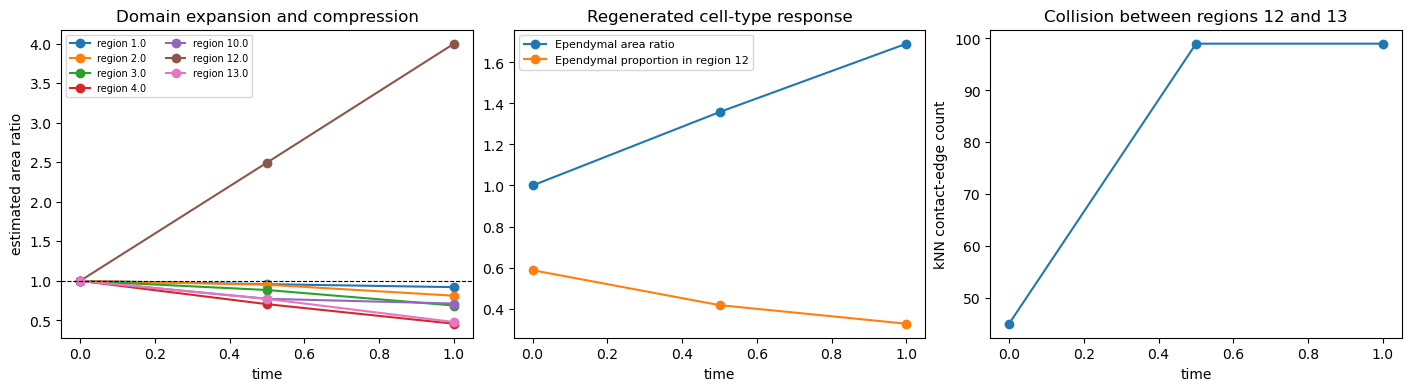

In [9]:
# ---------- trajectory plots ----------
focus_size_regions = numeric_sort(
    {
        "12.0",
        "13.0",
        *neighbors_active
    }
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(14, 3.8),
    constrained_layout=True
)

for r in focus_size_regions:
    sub = region_size_table[
        region_size_table["region"] == r
    ]
    axes[0].plot(
        sub["time"],
        sub["area_ratio"],
        marker="o",
        label=f"region {r}"
    )

axes[0].axhline(
    1.0,
    color="black",
    linewidth=0.8,
    linestyle="--"
)
axes[0].set(
    xlabel="time",
    ylabel="estimated area ratio",
    title="Domain expansion and compression"
)
axes[0].legend(
    fontsize=7,
    ncol=2
)

axes[1].plot(
    checks["time"],
    checks[
        f"{EXPECTED_CELLTYPE}_area_ratio"
    ],
    marker="o",
    label=f"{EXPECTED_CELLTYPE} area ratio"
)
axes[1].plot(
    checks["time"],
    checks[
        f"{EXPECTED_CELLTYPE}_proportion_region12"
    ],
    marker="o",
    label=f"{EXPECTED_CELLTYPE} proportion in region 12"
)
axes[1].set(
    xlabel="time",
    title="Regenerated cell-type response"
)
axes[1].legend(fontsize=8)

axes[2].plot(
    checks["time"],
    checks[
        "region12_13_contact_edges"
    ],
    marker="o"
)
axes[2].set(
    xlabel="time",
    ylabel="kNN contact-edge count",
    title="Collision between regions 12 and 13"
)

plt.savefig(
    OUT_DIR / "trajectory_checks.png",
    dpi=220,
    bbox_inches="tight"
)
plt.show()

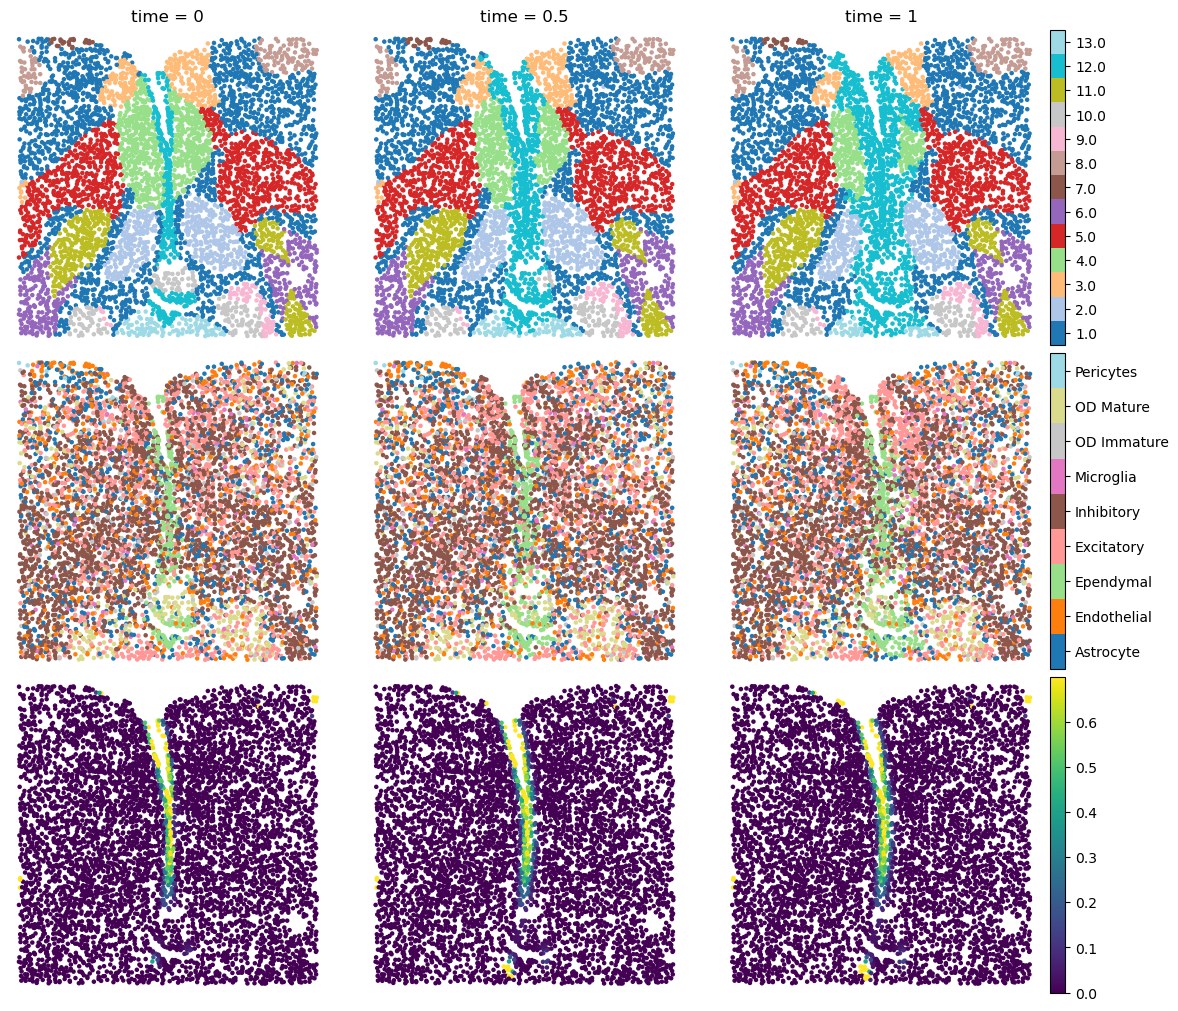

In [10]:
# ---------- maps: domain, regenerated cell type, and expected Nnat ----------
celltype_levels = numeric_sort(
    celltype_names
)

region_cmap = ListedColormap(
    plt.cm.tab20(
        np.linspace(
            0,
            1,
            max(1, len(region_levels))
        )
    )
)
celltype_cmap = ListedColormap(
    plt.cm.tab20(
        np.linspace(
            0,
            1,
            max(1, len(celltype_levels))
        )
    )
)

gene_values = [
    np.log1p(mu)
    for mu in plot_gene_mu_by_time
]
gene_vmax = np.percentile(
    np.concatenate(gene_values),
    99
)

xpad = 0.03 * np.ptp(
    xy[:, 0]
)
ypad = 0.03 * np.ptp(
    xy[:, 1]
)
xlim = (
    xy[:, 0].min() - xpad,
    xy[:, 0].max() + xpad
)
ylim = (
    xy[:, 1].max() + ypad,
    xy[:, 1].min() - ypad
)

fig, axes = plt.subplots(
    3,
    len(TIMES),
    figsize=(12, 10),
    constrained_layout=True
)

for h, t in enumerate(TIMES):
    region_code_t = pd.Categorical(
        regions_by_time[h],
        categories=region_levels
    ).codes
    celltype_code_t = pd.Categorical(
        celltypes_by_time[h],
        categories=celltype_levels
    ).codes

    sr = axes[0, h].scatter(
        xy[:, 0],
        xy[:, 1],
        c=region_code_t,
        s=5,
        cmap=region_cmap,
        vmin=-0.5,
        vmax=len(region_levels) - 0.5
    )

    scell = axes[1, h].scatter(
        xy[:, 0],
        xy[:, 1],
        c=celltype_code_t,
        s=5,
        cmap=celltype_cmap,
        vmin=-0.5,
        vmax=len(celltype_levels) - 0.5
    )

    sg = axes[2, h].scatter(
        xy[:, 0],
        xy[:, 1],
        c=gene_values[h],
        s=5,
        cmap="viridis",
        vmin=0,
        vmax=gene_vmax
    )

    axes[0, h].set_title(
        f"time = {t:g}"
    )

    for ax in axes[:, h]:
        ax.set_aspect("equal")
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        ax.axis("off")

axes[0, 0].set_ylabel(
    "Region",
    fontsize=13
)
axes[1, 0].set_ylabel(
    "Regenerated cell type",
    fontsize=13
)
axes[2, 0].set_ylabel(
    f"log1p(E[{PLOT_GENE}])",
    fontsize=13
)

cbar_r = fig.colorbar(
    sr,
    ax=axes[0, :],
    fraction=0.018,
    pad=0.01,
    ticks=np.arange(
        len(region_levels)
    )
)
cbar_r.ax.set_yticklabels(
    region_levels
)

cbar_c = fig.colorbar(
    scell,
    ax=axes[1, :],
    fraction=0.018,
    pad=0.01,
    ticks=np.arange(
        len(celltype_levels)
    )
)
cbar_c.ax.set_yticklabels(
    celltype_levels
)

fig.colorbar(
    sg,
    ax=axes[2, :],
    fraction=0.018,
    pad=0.01
)

plt.savefig(
    OUT_DIR
    / "A6_region_regenerated_celltype_expected_Nnat.png",
    dpi=220,
    bbox_inches="tight"
)
plt.show()

In [ ]:
# ---------- independently sampled Nnat counts ----------
sampled_values = [
    np.log1p(
        Y[:, gene_idx]
    )
    for Y in counts_by_time
]
sampled_vmax = np.percentile(
    np.concatenate(sampled_values),
    99
)

fig, axes = plt.subplots(
    1,
    len(TIMES),
    figsize=(12, 4),
    constrained_layout=True
)

for h, t in enumerate(TIMES):
    sg_sample = axes[h].scatter(
        xy[:, 0],
        xy[:, 1],
        c=sampled_values[h],
        s=5,
        cmap="viridis",
        vmin=0,
        vmax=sampled_vmax
    )
    axes[h].set_title(
        f"time = {t:g}"
    )
    axes[h].set_aspect("equal")
    axes[h].set_xlim(xlim)
    axes[h].set_ylim(ylim)
    axes[h].axis("off")

fig.colorbar(
    sg_sample,
    ax=axes,
    fraction=0.018,
    pad=0.01,
    label=f"log1p(sampled {PLOT_GENE})"
)

plt.savefig(
    OUT_DIR / "A6_sampled_Nnat_maps.png",
    dpi=220,
    bbox_inches="tight"
)
plt.show()

In [ ]:
# ---------- dedicated focus plot: regions 12 and 13 ----------
focus_regions = tuple(
    map(str, FOCUS_REGIONS)
)
focus_colors = {
    r: region_cmap(
        region_levels.index(r)
    )
    for r in focus_regions
}

fig, axes = plt.subplots(
    1,
    len(TIMES),
    figsize=(12, 4),
    constrained_layout=True
)

for h, t in enumerate(TIMES):
    labels_t = regions_by_time[h]
    focus_mask = np.isin(
        labels_t,
        focus_regions
    )

    axes[h].scatter(
        xy[~focus_mask, 0],
        xy[~focus_mask, 1],
        c="lightgray",
        s=4,
        alpha=0.18,
        linewidths=0
    )

    for r in focus_regions:
        mask = labels_t == r
        axes[h].scatter(
            xy[mask, 0],
            xy[mask, 1],
            c=[focus_colors[r]],
            s=6,
            linewidths=0,
            label=f"Region {r}"
        )

    axes[h].set_title(
        f"time = {t:g}"
    )
    axes[h].set_aspect("equal")
    axes[h].set_xlim(xlim)
    axes[h].set_ylim(ylim)
    axes[h].axis("off")

handles, labels = (
    axes[-1].get_legend_handles_labels()
)
axes[-1].legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.savefig(
    OUT_DIR / "A6_regions12_13_collision.png",
    dpi=220,
    bbox_inches="tight"
)
plt.show()

In [ ]:
# ---------- save outputs ----------
synthetic.write_h5ad(
    OUT_DIR
    / "A6_domain_timecourse_v4_NewCellType.h5ad"
)
checks.to_csv(
    OUT_DIR / "numerical_checks.csv",
    index=False
)
region_size_table.to_csv(
    OUT_DIR / "region_size_trajectory.csv",
    index=False
)

print(
    "Saved outputs to:",
    OUT_DIR.resolve()
)